In [188]:
from libs import *
from utilities import *

from Bio import SeqIO
import re
import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from tensorflow.keras import losses

import warnings
warnings.filterwarnings("ignore")


In [189]:
from Bio import SeqIO
import pandas as pd
import numpy as np

# Hydrophobicity scale (Kyte-Doolittle)
hydro_scale = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}

def extract_features(fasta_file):
    records = list(SeqIO.parse(fasta_file, "fasta"))
    features = []

    for record in records:
        seq = str(record.seq).upper()
        length = len(seq)

        # Amino acid composition
        counts = {aa: seq.count(aa) for aa in set(seq)}
        freq = {aa: counts.get(aa, 0) / length for aa in hydro_scale.keys()}

        # Hydrophobicity
        hydrophobicity = np.mean([hydro_scale.get(aa, 0) for aa in seq])

        # Cysteine count and pattern
        cysteine_count = seq.count('C')

        # Basic composition metrics
        gc_content = freq['G'] + freq['C']
        charge = freq['K'] + freq['R'] - freq['D'] - freq['E']
        aromaticity = freq['F'] + freq['Y'] + freq['W']

        # Motif checks (example: dibasic protease sites)
        has_dibasic_site = any(x in seq for x in ['KR', 'RR', 'RK'])

        features.append({
            'length': length,
            'hydrophobicity': hydrophobicity,
            'cysteine_count': cysteine_count,
            'gc_content': gc_content,
            'charge': charge,
            'aromaticity': aromaticity,
            'has_dibasic_site': int(has_dibasic_site),
            **freq
        })

    df = pd.DataFrame(features)
    return df

# Example usage
if __name__ == "__main__":
    df_new = extract_features("mango_data.fasta")
    df_new.to_csv("sspeptide_features.csv", index=False)


In [190]:
## Load data

In [191]:
df_new.head()

,length,hydrophobicity,cysteine_count,gc_content,charge,aromaticity,has_dibasic_site,A,R,N,...,L,K,M,F,P,S,T,W,Y,V
0,195,-0.830256,5,0.097436,0.076923,0.015385,1,0.066667,0.066667,0.025641,...,0.071795,0.138462,0.041026,0.015385,0.046154,0.087179,0.046154,0.000000,0.000000,0.061538
1,98,-0.502041,4,0.153061,-0.030612,0.091837,0,0.030612,0.061224,0.010204,...,0.061224,0.061224,0.020408,0.051020,0.030612,0.091837,0.030612,0.010204,0.030612,0.071429
2,196,-0.379082,5,0.142857,-0.025510,0.112245,1,0.030612,0.051020,0.035714,...,0.081633,0.056122,0.025510,0.061224,0.030612,0.086735,0.035714,0.010204,0.040816,0.056122
3,80,-1.118750,1,0.012500,-0.062500,0.075000,1,0.050000,0.062500,0.100000,...,0.087500,0.075000,0.037500,0.037500,0.012500,0.075000,0.012500,0.012500,0.025000,0.012500
4,177,-0.590395,3,0.045198,0.096045,0.084746,1,0.045198,0.039548,0.028249,...,0.084746,0.163842,0.050847,0.050847,0.045198,0.112994,0.050847,0.011299,0.022599,0.056497


In [192]:
result_signalp_mango = resultSignalP("../mango_signalp/prediction_results.txt")

In [193]:
df_new.columns.tolist()

['length',
 'hydrophobicity',
 'cysteine_count',
 'gc_content',
 'charge',
 'aromaticity',
 'has_dibasic_site',
 'A',
 'R',
 'N',
 'D',
 'C',
 'Q',
 'E',
 'G',
 'H',
 'I',
 'L',
 'K',
 'M',
 'F',
 'P',
 'S',
 'T',
 'W',
 'Y',
 'V']

In [194]:
numeric_cols = df_new.select_dtypes(include=[float, int]).columns.tolist()
scaler = StandardScaler()
df_standardized = df_new.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df_new[numeric_cols])

print("✅ Normalization done!")
print(df_standardized.head())

✅ Normalization done!
     length  hydrophobicity  cysteine_count  gc_content    charge  \
0  1.443114       -1.225879        0.726159    0.364855  1.021051   
1 -0.966081       -0.479074        0.365935    1.858607 -0.771797   
2  1.467951       -0.199298        0.726159    1.584589 -0.686735   
3 -1.413148       -1.882303       -0.714737   -1.915997 -1.303436   
4  0.996047       -0.680111        0.005711   -1.037938  1.339858   

   aromaticity  has_dibasic_site         A         R         N  ...         L  \
0    -2.027132          0.608035 -0.066382  0.424907 -0.809853  ... -0.638750   
1     0.247046         -1.644642 -1.217304  0.231287 -1.546049  ... -0.949969   
2     0.854116          0.608035 -1.217304 -0.131750 -0.329453  ... -0.349100   
3    -0.253786          0.608035 -0.598412  0.276667  2.736369  ... -0.176350   
4     0.036115          0.608035 -0.751709 -0.539910 -0.685496  ... -0.257442   

          K         M         F         P         S         T         W  \
0

In [195]:
label_mango,sequence_mango = readFastaFiles("mango_data.fasta")


In [196]:
len(sequence_mango)

5046

In [197]:
states = df_new.to_numpy().astype(np.float32)


In [198]:
states[0]

array([ 1.9500000e+02, -8.3025640e-01,  5.0000000e+00,  9.7435899e-02,
        7.6923080e-02,  1.5384615e-02,  1.0000000e+00,  6.6666670e-02,
        6.6666670e-02,  2.5641026e-02,  5.1282052e-02,  2.5641026e-02,
        5.1282052e-02,  7.6923080e-02,  7.1794875e-02,  2.0512821e-02,
        3.5897437e-02,  7.1794875e-02,  1.3846155e-01,  4.1025642e-02,
        1.5384615e-02,  4.6153847e-02,  8.7179489e-02,  4.6153847e-02,
        0.0000000e+00,  0.0000000e+00,  6.1538462e-02], dtype=float32)

In [199]:
states.shape

(5046, 27)

In [200]:
result_signalp_mango = resultSignalP("../mango_signalp/prediction_results.txt")

In [201]:
len(result_signalp_mango)

5046

In [202]:
unique, counts = np.unique(result_signalp_mango, return_counts=True)

In [203]:
#tape_data
mango_ebedding = np.load('sequence_mango.npy')

In [204]:
#ESM
embed2_mango = torch.load('embed2_mango.pt')

In [205]:
numpy_array_list = [tensor.numpy() for tensor in embed2_mango]
numpy_embed2_mango = np.array(numpy_array_list)

In [206]:
numpy_embed2_mango.shape

(5046, 1, 1280)

In [207]:
mango_ebedding2 = numpy_embed2_mango.reshape(numpy_embed2_mango.shape[0],numpy_embed2_mango.shape[2])


In [208]:
mango_ebedding2.shape

(5046, 1280)

In [209]:
len(embed2_mango)

5046

In [210]:
embedding_padded = np.concatenate((mango_ebedding, np.zeros((mango_ebedding.shape[0],16))), axis=1)
embedding2_padded = np.concatenate((mango_ebedding2, np.zeros((mango_ebedding2.shape[0],16))), axis=1)

In [211]:
shape_unit=28
embedding_images=np.reshape(embedding_padded,(embedding_padded.shape[0],shape_unit,shape_unit))

print(embedding_images.shape)

(5046, 28, 28)


In [212]:
shape_unit=36
embedding2_images=np.reshape(embedding2_padded,(embedding2_padded.shape[0],shape_unit,shape_unit))

print(embedding2_images.shape)

(5046, 36, 36)


In [213]:
#embedding_geotop = geotop_analysis(embedding_images)

In [214]:
#28*28
embedding_geotop = np.load("embedding_geotop_mango.npz")

In [215]:
#36*36
#embedding2_geotop = geotop_analysis(embedding2_images)

In [216]:
embedding2_geotop = np.load("embedding2_geotop_mango.npz")

In [217]:
embedding_geotop = [embedding_geotop['arr_'+str(i)] for i in range(len(embedding_geotop))]
embedding2_geotop = [embedding2_geotop['arr_'+str(i)] for i in range(len(embedding2_geotop))]

In [218]:
len(embedding2_geotop)

5046

In [219]:
# Trainning

In [220]:
### Tape and Geotop

In [221]:
dgms = gdr.DiagramSelector(use=True, point_type='finite').fit_transform(embedding_geotop)

In [222]:
dim = 1024
result = concate_embedding_geotop(mango_ebedding,dgms,dim)

In [223]:
#splitting the dataset
num_samples = len(result)
num_train_samples = int(0.8 * num_samples)  # 80% for training, 20% for testing

# Split data into training and testing sets
train_data, test_data = result[:num_train_samples], result[num_train_samples:]

In [224]:
shape_unit=32
std_scale = skp.StandardScaler().fit(train_data)
X_normalized = std_scale.transform(train_data)
train_data = np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [225]:
std_scale = skp.StandardScaler().fit(test_data)
X_normalized = std_scale.transform(test_data)
test_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [226]:
train_data_tape = np.expand_dims(train_data, -1)
test_data_tape = np.expand_dims(test_data, -1)

In [227]:
### ESM and Geotop

In [228]:
dgms = gdr.DiagramSelector(use=True, point_type='finite').fit_transform(embedding2_geotop)

In [229]:
dim = 1681
result = concate_embedding_geotop(mango_ebedding2,dgms,dim)

In [230]:
len(result)

5046

In [231]:
#splitting the dataset
#num_samples = len(result)
#num_train_samples = int(0.8 * num_samples)  # 80% for training, 20% for testing

# Split data into training and testing sets
train_data, test_data = result[:num_train_samples], result[num_train_samples:]
train_labels, test_labels = result_signalp_mango[:num_train_samples], result_signalp_mango[num_train_samples:]

In [232]:
shape_unit=41
std_scale = skp.StandardScaler().fit(train_data)
X_normalized = std_scale.transform(train_data)
train_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [233]:
std_scale = skp.StandardScaler().fit(test_data)
X_normalized = std_scale.transform(test_data)
test_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [234]:
train_data_esm = np.expand_dims(train_data, -1)
test_data_esm = np.expand_dims(test_data, -1)

In [235]:
len(test_data_esm)

1010

In [236]:
len(states)

5046

In [237]:
states_train, states_test = states[:num_train_samples], states[num_train_samples:]

In [238]:
num_train_samples

4036

In [240]:
states_test.shape

(1010, 27)

In [241]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

## Reinforcement Learning

In [242]:
# Hyperparameters
n_pretrain_epochs = 50
batch_size_pretrain = 64
n_episodes = 200
gamma = 0.99
policy_lr = 1e-4
value_lr = 1e-4
clf_lr = 1e-4
ent_coef = 0.02        # Entropy coefficient for exploration
print_every = 10
eps = 1e-8

In [243]:
# Build classifier (CNN for ESM / TAPE)
def build_classifier(shape, model_name=None):
    model = Sequential(name=model_name)
    model.add(layers.Conv2D(8, (3,3), padding="same", activation='relu', input_shape=(shape[0], shape[1],1)))
    model.add(layers.AveragePooling2D())
    model.add(layers.Conv2D(16, (3,3), padding="same", activation='relu'))
    model.add(layers.AveragePooling2D())
    model.add(layers.Conv2D(32, (3,3), padding="same", activation='relu'))
    model.add(layers.AveragePooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           bias_regularizer=regularizers.l2(1e-4),
                           activity_regularizer=regularizers.l2(1e-5)))
    model.add(layers.Dense(64, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           bias_regularizer=regularizers.l2(1e-4),
                           activity_regularizer=regularizers.l2(1e-5)))
    model.add(layers.Dense(1))  # logits output (no sigmoid)
    return model


In [244]:
# Policy Network
class PolicyNetwork(tf.keras.Model):
    def __init__(self, state_dim, hidden=(128, 64), dropout_rate=0.1):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.h1 = layers.Dense(hidden[0], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do1 = layers.Dropout(dropout_rate)
        self.h2 = layers.Dense(hidden[1], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do2 = layers.Dropout(dropout_rate)
        self.logit = layers.Dense(1, activation=None, kernel_initializer="glorot_uniform")

    def call(self, x, training=False):
        x = self.norm(x)
        x = self.h1(x); x = self.do1(x, training=training)
        x = self.h2(x); x = self.do2(x, training=training)
        return self.logit(x)

    @tf.function
    def sample(self, x, training=False, eps=1e-8):
        logit = self(x, training=training)
        p = tf.sigmoid(tf.clip_by_value(logit, -5.0, 5.0))
        u = tf.random.uniform(tf.shape(p))
        action = tf.cast(u < p, tf.float32)
        logp = action * tf.math.log(p + eps) + (1.0 - action) * tf.math.log(1.0 - p + eps)
        entropy = -(p * tf.math.log(p + eps) + (1.0 - p) * tf.math.log(1.0 - p + eps))
        return action, tf.reshape(logp, (-1,)), tf.reshape(entropy, (-1,)), p


In [245]:

# Value Network
class ValueNetwork(tf.keras.Model):
    def __init__(self, state_dim, hidden=(128, 64), dropout_rate=0.1):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.h1 = layers.Dense(hidden[0], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do1 = layers.Dropout(dropout_rate)
        self.h2 = layers.Dense(hidden[1], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do2 = layers.Dropout(dropout_rate)
        self.v_out = layers.Dense(1, activation=None, kernel_initializer="glorot_uniform")

    def call(self, x, training=False):
        x = self.norm(x)
        x = self.h1(x); x = self.do1(x, training=training)
        x = self.h2(x); x = self.do2(x, training=training)
        return self.v_out(x)

In [246]:
#  Losses and Optimizers
loss_fn = losses.BinaryCrossentropy(from_logits=True, reduction=losses.Reduction.NONE)
clf_optimizer = optimizers.Adam(clf_lr)
policy_optimizer = optimizers.Adam(policy_lr, clipnorm=1.0)
value_optimizer = optimizers.Adam(value_lr, clipnorm=1.0)
value_loss_fn = tf.keras.losses.MeanSquaredError()

#  Build models
dim_ESM = train_data_esm.shape[1:3]
dim_TAPE = train_data_tape.shape[1:3]
classifier_ESM = build_classifier(dim_ESM, "classifier_ESM")
classifier_TAPE = build_classifier(dim_TAPE, "classifier_TAPE")
state_dim = states_train.shape[1]
policy = PolicyNetwork(state_dim)
value_net = ValueNetwork(state_dim)


In [247]:
#  Labels reshaping
if y_train.ndim == 1:
    y_train = y_train.reshape(-1, 1)

In [248]:
def pretrain_classifier(model, X, y, epochs=5, batch_size=64):
    dataset = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(1000).batch(batch_size)
    opt = optimizers.Adam(clf_lr)
    for epoch in range(epochs):
        epoch_losses = []
        for Xb, yb in dataset:
            if yb.ndim == 1:
                yb = tf.reshape(yb, (-1,1))
            with tf.GradientTape() as t:
                logits = model(Xb, training=True)
                loss_vals = loss_fn(yb, logits)
                loss = tf.reduce_mean(loss_vals)
            grads = t.gradient(loss, model.trainable_variables)
            opt.apply_gradients(zip(grads, model.trainable_variables))
            epoch_losses.append(loss.numpy())
        print(f"[Pretrain] {model.name} epoch {epoch+1}/{epochs} loss={np.mean(epoch_losses):.4f}")

print("=> Pretraining classifiers...")
pretrain_classifier(classifier_ESM, train_data_esm, y_train, epochs=n_pretrain_epochs, batch_size=batch_size_pretrain)
pretrain_classifier(classifier_TAPE, train_data_tape, y_train, epochs=n_pretrain_epochs, batch_size=batch_size_pretrain)

classifier_ESM.trainable = False
classifier_TAPE.trainable = False

=> Pretraining classifiers...
[Pretrain] classifier_ESM epoch 1/50 loss=0.4649
[Pretrain] classifier_ESM epoch 2/50 loss=0.2326
[Pretrain] classifier_ESM epoch 3/50 loss=0.2310
[Pretrain] classifier_ESM epoch 4/50 loss=0.2296
[Pretrain] classifier_ESM epoch 5/50 loss=0.2358
[Pretrain] classifier_ESM epoch 6/50 loss=0.2340
[Pretrain] classifier_ESM epoch 7/50 loss=0.2217
[Pretrain] classifier_ESM epoch 8/50 loss=0.2131
[Pretrain] classifier_ESM epoch 9/50 loss=0.1979
[Pretrain] classifier_ESM epoch 10/50 loss=0.1776
[Pretrain] classifier_ESM epoch 11/50 loss=0.1574
[Pretrain] classifier_ESM epoch 12/50 loss=0.1377
[Pretrain] classifier_ESM epoch 13/50 loss=0.1281
[Pretrain] classifier_ESM epoch 14/50 loss=0.1221
[Pretrain] classifier_ESM epoch 15/50 loss=0.1171
[Pretrain] classifier_ESM epoch 16/50 loss=0.1214
[Pretrain] classifier_ESM epoch 17/50 loss=0.1169
[Pretrain] classifier_ESM epoch 18/50 loss=0.1141
[Pretrain] classifier_ESM epoch 19/50 loss=0.1069
[Pretrain] classifier_ESM epo

In [249]:
# Evaluation function
def eval_classifier(model, X, y):
    if y.ndim == 1:
        y = y.reshape(-1,1)
    logits = model(X, training=False)
    preds = tf.sigmoid(logits) > 0.5
    acc = np.mean((preds.numpy().astype(np.float32) == y.astype(np.float32)))
    avg_loss = np.mean(loss_fn(y, logits).numpy())
    return acc, avg_loss

hold_idx = np.random.choice(len(states_train), size=min(500, len(states_train)), replace=False)
y_hold = y_train[hold_idx]
acc_esm, loss_esm = eval_classifier(classifier_ESM, train_data_esm[hold_idx], y_hold)
acc_tape, loss_tape = eval_classifier(classifier_TAPE, train_data_tape[hold_idx], y_hold)
print(f"[Eval holdout] ESM acc={acc_esm:.4f} loss={loss_esm:.4f} | TAPE acc={acc_tape:.4f} loss={loss_tape:.4f}")


[Eval holdout] ESM acc=0.9720 loss=0.0965 | TAPE acc=0.9660 loss=0.1084


In [250]:
# Actor–Critic RL loop
N = len(states_train)

for episode in range(1, n_episodes + 1):
    idx = np.random.permutation(N)

    log_probs_list, rewards_list, chosen_idxs, true_labels, preds_for_acc = [], [], [], [], []

    for i in idx:
        # --- State sampling and policy decision ---
        state_sample = tf.convert_to_tensor(states_train[i:i+1], dtype=tf.float32)
        action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
        log_probs_list.append(logp)

        # --- Choose classifier based on policy action ---
        if int(action.numpy().flatten()[0]) == 0:
            classifier = classifier_ESM
            X_sample = train_data_esm[i:i+1]
        else:
            classifier = classifier_TAPE
            X_sample = train_data_tape[i:i+1]

        y_sample = y_train[i:i+1]
        if y_sample.ndim == 1:
            y_sample = y_sample.reshape(-1, 1)

        # --- Get logits from both classifiers ---
        logits_esm  = classifier_ESM(tf.convert_to_tensor(train_data_esm[i:i+1], dtype=tf.float32), training=False)
        logits_tape = classifier_TAPE(tf.convert_to_tensor(train_data_tape[i:i+1], dtype=tf.float32), training=False)
        logits_chosen = logits_esm if int(action.numpy().flatten()[0]) == 0 else logits_tape
        logits_other  = logits_tape if int(action.numpy().flatten()[0]) == 0 else logits_esm

        # --- Predictions and correctness ---
        p_chosen = tf.sigmoid(logits_chosen)
        p_other  = tf.sigmoid(logits_other)
        y_val = tf.convert_to_tensor(y_sample, dtype=tf.float32)
        is_correct = float((p_chosen.numpy().flatten()[0] > 0.5) == (y_val.numpy().flatten()[0] > 0.5))

        # --- Compute losses and prediction errors ---
        loss_chosen = tf.reduce_mean(loss_fn(y_val, logits_chosen))
        err_chosen = tf.abs(y_val - p_chosen)
        err_other  = tf.abs(y_val - p_other)

        # =======================================================
        #  Reward Equation
        # R_t = -loss_chosen + I_correct - | |y - σ(z_chosen)| - |y - σ(z_other)| |
        # =======================================================
        reward = -0.1 * loss_chosen + 1.0 * is_correct - tf.abs(err_chosen - err_other)
        reward = tf.reduce_mean(reward)
        rewards_list.append(tf.reshape(reward, (-1,)))

        # --- Logging ---
        preds_for_acc.append(float(p_chosen.numpy().flatten()[0] > 0.5))
        chosen_idxs.append(int(action.numpy().flatten()[0]))
        true_labels.append(float(y_sample.flatten()[0]))

    # --- Discounted rewards ---
    rewards_np = np.array([r.numpy()[0] for r in rewards_list])
    discounted = []
    R = 0.0
    for r in reversed(rewards_np):
        R = r + gamma * R
        discounted.insert(0, R)
    discounted = tf.convert_to_tensor(discounted, dtype=tf.float32)
    discounted = (discounted - tf.reduce_mean(discounted)) / (tf.math.reduce_std(discounted) + 1e-8)

    # --- Prepare tensors ---
    states_batch = tf.convert_to_tensor(states_train[idx], dtype=tf.float32)
    actions_taken = tf.reshape(tf.convert_to_tensor(chosen_idxs, dtype=tf.float32), (-1, 1))

    # ===== Value Network Update =====
    with tf.GradientTape() as tape_v:
        values = tf.squeeze(value_net(states_batch, training=True), axis=-1)
        v_loss = value_loss_fn(discounted, values)
    v_grads = tape_v.gradient(v_loss, value_net.trainable_variables)
    value_optimizer.apply_gradients(zip(v_grads, value_net.trainable_variables))

    # ===== Policy Network Update =====
    with tf.GradientTape() as tape_pg:
        logits_batch = policy(states_batch, training=True)
        probs_batch = tf.sigmoid(tf.clip_by_value(logits_batch, -5.0, 5.0))
        logp_batch = actions_taken * tf.math.log(probs_batch + eps) + (1.0 - actions_taken) * tf.math.log(1.0 - probs_batch + eps)
        logp_batch = tf.reshape(logp_batch, (-1,))

        values = tf.squeeze(value_net(states_batch, training=False), axis=-1)
        advantages = discounted - tf.stop_gradient(values)
        advantages = (advantages - tf.reduce_mean(advantages)) / (tf.math.reduce_std(advantages) + 1e-8)

        entropy_batch = -(probs_batch * tf.math.log(probs_batch + eps)
                          + (1.0 - probs_batch) * tf.math.log(1.0 - probs_batch + eps))
        entropy_batch = tf.reshape(entropy_batch, (-1,))

        pg_loss = -tf.reduce_mean(logp_batch * advantages) - ent_coef * tf.reduce_mean(entropy_batch)

    pg_grads = tape_pg.gradient(pg_loss, policy.trainable_variables)
    policy_optimizer.apply_gradients(zip(pg_grads, policy.trainable_variables))

    # --- Logging ---
    avg_reward = np.mean(rewards_np)
    policy_loss_val = pg_loss.numpy()
    overall_acc = np.mean(np.array(preds_for_acc) == np.array(true_labels))
    mean_prob = tf.reduce_mean(tf.sigmoid(policy(tf.convert_to_tensor(states_train, dtype=tf.float32)))).numpy()

    if episode % print_every == 0 or episode == 1:
        acc_esm_hold, loss_esm_hold = eval_classifier(classifier_ESM, train_data_esm[hold_idx], y_hold)
        acc_tape_hold, loss_tape_hold = eval_classifier(classifier_TAPE, train_data_tape[hold_idx], y_hold)
        print(f"Episode {episode}/{n_episodes} | avg_reward={avg_reward:.4f} | policy_loss={policy_loss_val:.6f} | "
              f"value_loss={v_loss.numpy():.6f} | overall_acc={overall_acc:.4f} | mean_policy_prob={mean_prob:.3f}")
        print(f"  holdout ESM acc={acc_esm_hold:.4f} loss={loss_esm_hold:.4f} | TAPE acc={acc_tape_hold:.4f} loss={loss_tape_hold:.4f}")


Episode 1/200 | avg_reward=0.9103 | policy_loss=-0.009503 | value_loss=2.502716 | overall_acc=0.9718 | mean_policy_prob=0.576
  holdout ESM acc=0.9720 loss=0.0965 | TAPE acc=0.9660 loss=0.1084
Episode 10/200 | avg_reward=0.9079 | policy_loss=-0.017503 | value_loss=1.951740 | overall_acc=0.9698 | mean_policy_prob=0.523
  holdout ESM acc=0.9720 loss=0.0965 | TAPE acc=0.9660 loss=0.1084
Episode 20/200 | avg_reward=0.9086 | policy_loss=-0.015612 | value_loss=1.958537 | overall_acc=0.9703 | mean_policy_prob=0.531
  holdout ESM acc=0.9720 loss=0.0965 | TAPE acc=0.9660 loss=0.1084
Episode 30/200 | avg_reward=0.9094 | policy_loss=-0.022020 | value_loss=1.926706 | overall_acc=0.9710 | mean_policy_prob=0.545
  holdout ESM acc=0.9720 loss=0.0965 | TAPE acc=0.9660 loss=0.1084
Episode 40/200 | avg_reward=0.9096 | policy_loss=-0.006384 | value_loss=1.777025 | overall_acc=0.9713 | mean_policy_prob=0.560
  holdout ESM acc=0.9720 loss=0.0965 | TAPE acc=0.9660 loss=0.1084
Episode 50/200 | avg_reward=0.

In [251]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Evaluate ESM Classifier ----
y_pred_esm = classifier_ESM.predict(test_data_esm)
y_pred_esm_binary = (y_pred_esm > 0.5).astype(int)

print("\n ESM Classifier Performance:")
print("Accuracy:", accuracy_score(test_labels, y_pred_esm_binary))
print("Precision:", precision_score(test_labels, y_pred_esm_binary))
print("Recall:", recall_score(test_labels, y_pred_esm_binary))
print("F1 Score:", f1_score(test_labels, y_pred_esm_binary))
print("ROC-AUC:", roc_auc_score(test_labels, y_pred_esm))

# ---- Evaluate TAPE Classifier ----
y_pred_tape = classifier_TAPE.predict(test_data_tape)
y_pred_tape_binary = (y_pred_tape > 0.5).astype(int)

print("\n TAPE Classifier Performance:")
print("Accuracy:", accuracy_score(test_labels, y_pred_tape_binary))
print("Precision:", precision_score(test_labels, y_pred_tape_binary))
print("Recall:", recall_score(test_labels, y_pred_tape_binary))
print("F1 Score:", f1_score(test_labels, y_pred_tape_binary))
print("ROC-AUC:", roc_auc_score(test_labels, y_pred_tape))


32/32 [==============================] - 0s 5ms/step

 ESM Classifier Performance:
Accuracy: 0.9584158415841584
Precision: 0.8
Recall: 0.5555555555555556
F1 Score: 0.6557377049180328
ROC-AUC: 0.9309997630893154
32/32 [==============================] - 0s 4ms/step

 TAPE Classifier Performance:
Accuracy: 0.9613861386138614
Precision: 0.7894736842105263
Recall: 0.625
F1 Score: 0.6976744186046512
ROC-AUC: 0.9304074863776355


In [252]:
esm_count, tape_count = 0, 0

for i in range(len(states_test)):
    state_sample = tf.convert_to_tensor(states_test[i:i+1], dtype=tf.float32)
    action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
    log_probs_list.append(logp)

    if int(action.numpy().flatten()[0]) == 0:
        esm_count += 1
    else:
        tape_count += 1


print("\n Policy Selection Summary:")
print(f"Chose ESM:  {esm_count} samples ({esm_count/len(states_test)*100:.1f}%)")
print(f"Chose TAPE: {tape_count} samples ({tape_count/len(states_test)*100:.1f}%)")


 Policy Selection Summary:
Chose ESM:  488 samples (48.3%)
Chose TAPE: 522 samples (51.7%)


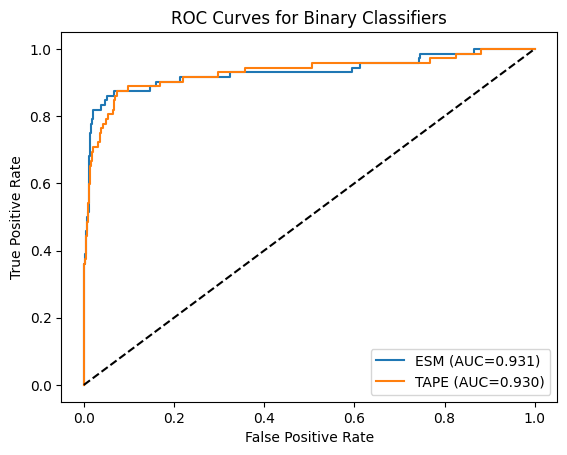

In [253]:
fpr_esm, tpr_esm, _ = roc_curve(test_labels, y_pred_esm)
fpr_tape, tpr_tape, _ = roc_curve(test_labels, y_pred_tape)

plt.plot(fpr_esm, tpr_esm, label='ESM (AUC=%.3f)' % roc_auc_score(test_labels, y_pred_esm))
plt.plot(fpr_tape, tpr_tape, label='TAPE (AUC=%.3f)' % roc_auc_score(test_labels, y_pred_tape))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curves for Binary Classifiers')
plt.show()


In [254]:
correct = 0
pred_rl = []
for i in range(len(states_test)):
    state_sample = tf.convert_to_tensor(states_test[i:i+1], dtype=tf.float32)
    action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
    log_probs_list.append(logp)

    if int(action.numpy().flatten()[0]) == 0:
        classifier = classifier_ESM
        X_sample = test_data_esm[i:i+1]
    else:
        classifier = classifier_TAPE
        X_sample = test_data_tape[i:i+1]

    y_sample = y_test[i:i+1]
    if y_sample.ndim == 1:
        y_sample = y_sample.reshape(-1,1)

    logits_clf = classifier(tf.convert_to_tensor(X_sample, dtype=tf.float32), training=False)
    loss_scalar = tf.reduce_mean(loss_fn(y_sample, logits_clf))
    pred = tf.cast(tf.sigmoid(logits_clf) > 0.5, tf.float32)
    pred_rl.append(pred.numpy().flatten()[0])
    
    # Count correct predictions
    #is_correct = 1.0 if (pred.numpy().flatten()[0] == y_sample.flatten()[0]) else 0.0
    if pred.numpy().flatten()[0] == y_test[i]:
        correct += 1

accuracy = correct / len(states_test)
print("\n✅ Test accuracy with learned policy:", accuracy)



✅ Test accuracy with learned policy: 0.9663366336633663


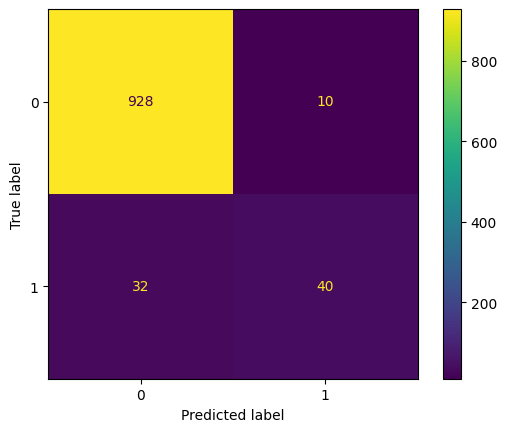

In [255]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_labels, y_pred_esm_binary)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

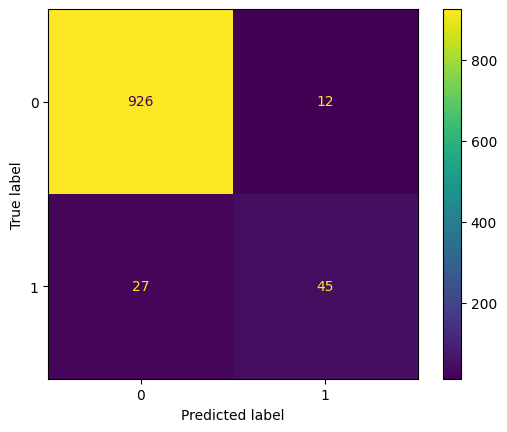

In [256]:
cm = confusion_matrix(test_labels, y_pred_tape_binary)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

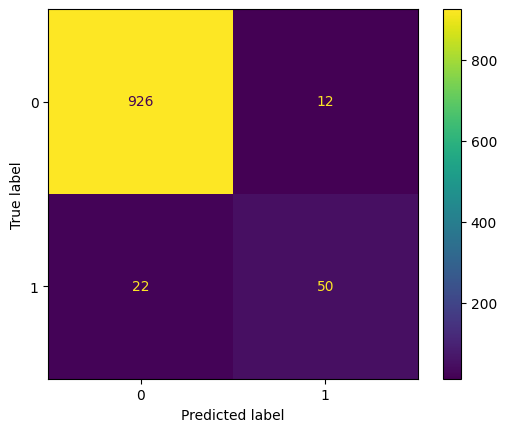

In [257]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_labels, pred_rl)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.show()